# 🎲 Step 8b — PINN vs. Plain MLP: Seed-Robustness Check
### Is the PINN's small edge over the plain MLP (Step 8) real, or initialization noise?

---
Step 8's single run found PINN and plain MLP statistically indistinguishable across
all three evaluation tracks (deltas of 0.001-0.003 AUC) -- too small to tell apart from
seed-to-seed noise on one run. This notebook re-trains **only PlainMLP and PINN**
(not LR/RF/XGBoost -- not the open question) across 5 random model-training seeds,
reusing the **exact same data splits, spatial-CV folds, and leave-one-region-out
regions** as Step 8 (all deterministic from `RANDOM_STATE=42`, independent of the
model-training seed being varied here), and reports a bootstrap confidence interval on
the PINN-minus-MLP AUC delta per track.

**Compute-budget note:** Track B2 (leave-one-region-out) is the most expensive part
per seed (6 regions x 2 models), so it uses 3 seeds instead of 5; Track A and Track B1
use the full 5. `LAMBDA_PHYS=0.1` is carried over from Step 8's ablation, not
re-selected here -- re-running the ablation per seed would be a different (larger)
question than the one this notebook answers.

**Kernel:** `firerisk-anaconda3` (same as Step 8).


## 📦 Step 0 — Install Required Libraries

In [1]:
import subprocess, sys
packages = ["numpy==2.5.1", "pandas>=3.0", "matplotlib>=3.10", "scipy>=1.16",
            "scikit-learn>=1.9", "geopandas", "pyogrio", "pyarrow", "psutil"]
for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")
print("Library installation complete.")


Library installation complete.


## 📚 Step 1 — Imports & Instrumentation

In [2]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import torch
import torch.nn as nn
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

PIPELINE_T0 = time.time()
_process = psutil.Process(os.getpid())

def now_mem_gb():
    return _process.memory_info().rss / 1e9

def log_step(label, t0, mem0=None):
    elapsed = time.time() - t0
    msg = f"   [{label}] {elapsed:.2f} sec"
    if mem0 is not None:
        msg += f"  |  memory: {mem0:.2f} GB -> {now_mem_gb():.2f} GB"
    print(msg)
    return elapsed

print(f"CPU cores available: {os.cpu_count()}")
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")


CPU cores available: 24
torch 2.12.1+cpu | cuda available: False


## ⚙️ Step 2 — Configuration
Identical `RANDOM_STATE`, `DROP_COLS`, `DRYNESS_SIGNS`, spatial-block/region
construction as Step 8 -- this is what guarantees the splits/folds/regions here are
bit-identical to Step 8's, so only the model-training seed differs.

In [3]:
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
INTEGRATED_DIR = os.path.join(BASE_DIR, "Integrated_Analysis")
PIXELS_PARQUET = os.path.join(INTEGRATED_DIR, "Integrated_Outputs", "Integrated_FireRisk_Pixels.parquet")
STATE_SHP = os.path.join(BASE_DIR, "LST_analysis", "India_State_Boundary.shp")
OUTPUT_DIR = os.path.join(BASE_DIR, "Physics_Informed_FireRisk_Model", "Model_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42          # controls the DATA split/folds/regions -- same as Step 8
TARGET_COL = "fire_ever"
DROP_COLS = ["lon", "lat", "fire_count", TARGET_COL]

DRYNESS_SIGNS = {
    "fldas_airtemp_anomaly": +1, "fldas_rh_anomaly": -1,
    "fldas_soilmoisture_anomaly": -1, "fldas_precip_anomaly": -1,
    "fldas_airtemp_mk_tau_monthly": +1, "fldas_rh_mk_tau_monthly": -1,
    "fldas_soilmoisture_mk_tau_monthly": -1, "fldas_precip_mk_tau_monthly": -1,
}

BATCH_SIZE = 8192
NN_HIDDEN = (128, 64, 32)
NN_DROPOUT = (0.3, 0.3, 0.2)
LAMBDA_PHYS = 0.1   # carried over from Step 8's ablation -- not re-selected here

NN_EPOCHS_FULL, NN_PATIENCE_FULL = 50, 7     # Track A budget (matches Step 8)
NN_EPOCHS_CV, NN_PATIENCE_CV = 15, 4          # Track B1/B2 budget (matches Step 8)

N_SPATIAL_FOLDS = 3
N_REGIONS = 6

MODEL_SEEDS_A_B1 = [42, 123, 456, 789, 2024]   # 5 seeds
MODEL_SEEDS_B2 = [42, 123, 456]                  # 3 seeds -- B2 is the expensive one

print(f"Model-training seeds: A/B1={MODEL_SEEDS_A_B1}, B2={MODEL_SEEDS_B2}")
print(f"LAMBDA_PHYS (carried over from Step 8): {LAMBDA_PHYS}")


Model-training seeds: A/B1=[42, 123, 456, 789, 2024], B2=[42, 123, 456]
LAMBDA_PHYS (carried over from Step 7): 0.1


## 📂 Step 3 — Load Data & Reproduce Step 8's Splits/Folds/Regions

In [4]:
t0 = time.time()
df = pd.read_parquet(PIXELS_PARQUET)
log_step("Parquet load", t0)
feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"Dataset: {len(df):,} pixels x {len(feature_cols)} features")

X_full = df[feature_cols].fillna(df[feature_cols].median())
y_full = df[TARGET_COL].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)
print(f"Track A split: train={len(X_train):,} test={len(X_test):,} (bit-identical to Step 8)")

block_id_full = (np.floor(df["lon"] / 2).astype(int).astype(str) + "_" +
                  np.floor(df["lat"] / 2).astype(int).astype(str))
gkf = GroupKFold(n_splits=N_SPATIAL_FOLDS)
spatial_folds = list(gkf.split(df, groups=block_id_full))   # deterministic given block_id_full
print(f"Track B1: {len(spatial_folds)} spatial folds reproduced (GroupKFold has no randomness)")

state_gdf = gpd.read_file(STATE_SHP)
if state_gdf.crs is None:
    state_gdf = state_gdf.set_crs("EPSG:3857")
state_gdf = state_gdf.to_crs("EPSG:4326")
state_gdf["state_id"] = range(len(state_gdf))
centroids = np.array([[geom.centroid.x, geom.centroid.y] for geom in state_gdf.geometry])
region_labels = KMeans(n_clusters=N_REGIONS, random_state=RANDOM_STATE, n_init=10).fit_predict(centroids)
state_gdf["region_id"] = region_labels
pts = gpd.GeoDataFrame(df[["lon", "lat"]].copy(),
                        geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
joined = gpd.sjoin(pts, state_gdf[["state_id", "region_id", "geometry"]], predicate="within", how="left")
joined = joined[~joined.index.duplicated(keep="first")]
df["region_id"] = joined["region_id"].reindex(df.index)
df_matched = df.dropna(subset=["region_id"])
print(f"Track B2: {df_matched['region_id'].nunique()} regions reproduced, "
      f"{len(df)-len(df_matched):,} unmatched pixels dropped")


   [Parquet load] 0.25 sec
Dataset: 4,161,009 pixels x 52 features


Track A split: train=3,328,807 test=832,202 (bit-identical to Step 7)


Track B1: 3 spatial folds reproduced (GroupKFold has no randomness)


Track B2: 6 regions reproduced, 0 unmatched pixels dropped


## 🌵 Step 4 — Dryness Proxy + Shared MLP/PINN Training Function
Identical to Step 8's, with one addition: `train_nn` now takes an explicit `seed`
argument and calls `torch.manual_seed(seed)` right before building the model --
that single call controls both the weight initialization and the batch-shuffle
order for that run, since nothing else touches the global RNG in between.

In [5]:
def fit_dryness_stats(X_fit):
    return {c: (float(X_fit[c].mean()), float(X_fit[c].std()) or 1.0) for c in DRYNESS_SIGNS}

def compute_dryness_proxy(X_part, stats):
    proxy = np.zeros(len(X_part), dtype=np.float64)
    for c, sign in DRYNESS_SIGNS.items():
        mean, std = stats[c]
        std = std if std > 1e-9 else 1.0
        proxy += sign * (X_part[c].values - mean) / std
    return proxy


class TabularNet(nn.Module):
    def __init__(self, in_dim, hidden=NN_HIDDEN, dropout=NN_DROPOUT):
        super().__init__()
        layers = []
        prev = in_dim
        for h, p in zip(hidden, dropout):
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_nn(X_tr_df, y_tr, physics, max_epochs, patience, seed, lambda_phys=LAMBDA_PHYS):
    torch.manual_seed(seed)   # controls weight init AND batch shuffle order for this run
    Xt_df, Xv_df, yt, yv = train_test_split(X_tr_df, y_tr, test_size=0.1, stratify=y_tr,
                                             random_state=RANDOM_STATE)
    scaler = StandardScaler().fit(Xt_df)
    Xt_s, Xv_s = scaler.transform(Xt_df), scaler.transform(Xv_df)

    dstats, physics_idx = None, None
    if physics:
        dstats = fit_dryness_stats(Xt_df)
        dry_t = compute_dryness_proxy(Xt_df, dstats).astype(np.float32)
        dry_v = compute_dryness_proxy(Xv_df, dstats).astype(np.float32)
        Xt_final = np.hstack([Xt_s, dry_t.reshape(-1, 1)]).astype(np.float32)
        Xv_final = np.hstack([Xv_s, dry_v.reshape(-1, 1)]).astype(np.float32)
        physics_idx = Xt_final.shape[1] - 1
    else:
        Xt_final, Xv_final = Xt_s.astype(np.float32), Xv_s.astype(np.float32)

    model = TabularNet(in_dim=Xt_final.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)
    pos_weight = torch.tensor([(yt == 0).sum() / max((yt == 1).sum(), 1)], dtype=torch.float32)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    Xt_tensor = torch.tensor(Xt_final, dtype=torch.float32)
    yt_tensor = torch.tensor(yt.values, dtype=torch.float32)
    Xv_tensor = torch.tensor(Xv_final, dtype=torch.float32)

    n = Xt_tensor.shape[0]
    best_auc, best_state, bad_epochs = -1.0, None, 0
    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        for start in range(0, n, BATCH_SIZE):
            b_idx = perm[start:start + BATCH_SIZE]
            yb = yt_tensor[b_idx]
            if physics:
                xb = Xt_tensor[b_idx].clone().requires_grad_(True)
                logits = model(xb)
                data_loss = bce(logits.squeeze(1), yb)
                grads = torch.autograd.grad(logits, xb, grad_outputs=torch.ones_like(logits),
                                             create_graph=True)[0]
                phys_pen = torch.relu(-grads[:, physics_idx]).pow(2).mean()
                loss = data_loss + lambda_phys * phys_pen
            else:
                xb = Xt_tensor[b_idx]
                loss = bce(model(xb).squeeze(1), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model(Xv_tensor).squeeze(1)).numpy()
        val_auc = roc_auc_score(yv, val_probs)
        sched.step(val_auc)
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return {"model": model, "scaler": scaler, "physics": physics,
            "dryness_stats": dstats, "physics_idx": physics_idx}


def predict_nn(bundle, X_df):
    model, scaler = bundle["model"], bundle["scaler"]
    Xs = scaler.transform(X_df)
    if bundle["physics"]:
        dry = compute_dryness_proxy(X_df, bundle["dryness_stats"]).astype(np.float32)
        Xfinal = np.hstack([Xs, dry.reshape(-1, 1)]).astype(np.float32)
    else:
        Xfinal = Xs.astype(np.float32)
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(Xfinal, dtype=torch.float32)).squeeze(1)).numpy()

print("Shared functions ready.")


Shared functions ready.


## 🏋️ Step 5 — Track A Seed Sweep (random split, full budget, 5 seeds)

In [6]:
trackA_seed_rows = []
for seed in MODEL_SEEDS_A_B1:
    for physics, name in [(False, "PlainMLP"), (True, "PINN")]:
        t0 = time.time()
        bundle = train_nn(X_train, y_train, physics=physics, max_epochs=NN_EPOCHS_FULL,
                           patience=NN_PATIENCE_FULL, seed=seed)
        auc = roc_auc_score(y_test, predict_nn(bundle, X_test))
        elapsed = time.time() - t0
        trackA_seed_rows.append({"track": "A", "model": name, "seed": seed, "roc_auc": auc,
                                  "train_seconds": elapsed})
        print(f"   [Track A] seed={seed:<5} {name:<10} AUC={auc:.4f}  ({elapsed:.1f}s)")

trackA_seed_df = pd.DataFrame(trackA_seed_rows)
print(f"\nTrack A done: {len(trackA_seed_df)} fits")


   [Track A] seed=42    PlainMLP   AUC=0.9614  (257.0s)


   [Track A] seed=42    PINN       AUC=0.9612  (429.8s)


   [Track A] seed=123   PlainMLP   AUC=0.9613  (261.5s)


   [Track A] seed=123   PINN       AUC=0.9614  (419.6s)


   [Track A] seed=456   PlainMLP   AUC=0.9614  (248.8s)


   [Track A] seed=456   PINN       AUC=0.9614  (417.6s)


   [Track A] seed=789   PlainMLP   AUC=0.9614  (253.4s)


   [Track A] seed=789   PINN       AUC=0.9614  (428.2s)


   [Track A] seed=2024  PlainMLP   AUC=0.9614  (261.7s)


   [Track A] seed=2024  PINN       AUC=0.9614  (413.2s)

Track A done: 10 fits


## 🗺️ Step 6 — Track B1 Seed Sweep (spatial block CV, reduced budget, 5 seeds x 3 folds)

In [7]:
trackB1_seed_rows = []
for seed in MODEL_SEEDS_A_B1:
    for fold, (tr_idx, te_idx) in enumerate(spatial_folds):
        df_tr, df_te = df.iloc[tr_idx], df.iloc[te_idx]
        if df_te[TARGET_COL].sum() < 50:
            continue
        Xf_tr = df_tr[feature_cols].fillna(df_tr[feature_cols].median())
        yf_tr = df_tr[TARGET_COL].astype(int)
        Xf_te = df_te[feature_cols].fillna(df_tr[feature_cols].median())
        yf_te = df_te[TARGET_COL].astype(int)

        for physics, name in [(False, "PlainMLP"), (True, "PINN")]:
            t0 = time.time()
            bundle = train_nn(Xf_tr, yf_tr, physics=physics, max_epochs=NN_EPOCHS_CV,
                               patience=NN_PATIENCE_CV, seed=seed)
            auc = roc_auc_score(yf_te, predict_nn(bundle, Xf_te))
            elapsed = time.time() - t0
            trackB1_seed_rows.append({"track": "B1", "model": name, "seed": seed, "fold": fold,
                                       "roc_auc": auc, "train_seconds": elapsed})
        print(f"   [Track B1] seed={seed:<5} fold={fold} done ({elapsed:.1f}s/model)")

trackB1_seed_df = pd.DataFrame(trackB1_seed_rows)
print(f"\nTrack B1 done: {len(trackB1_seed_df)} fits")


   [Track B1] seed=42    fold=0 done (103.2s/model)


   [Track B1] seed=42    fold=1 done (103.3s/model)


   [Track B1] seed=42    fold=2 done (103.2s/model)


   [Track B1] seed=123   fold=0 done (103.7s/model)


   [Track B1] seed=123   fold=1 done (103.9s/model)


...

   [Track B1] seed=789   fold=1 done (102.6s/model)


   [Track B1] seed=789   fold=2 done (101.9s/model)


   [Track B1] seed=2024  fold=0 done (104.3s/model)


   [Track B1] seed=2024  fold=1 done (102.2s/model)


   [Track B1] seed=2024  fold=2 done (103.8s/model)

Track B1 done: 30 fits


## 🌍 Step 7 — Track B2 Seed Sweep (leave-one-region-out, reduced budget, 3 seeds x 6 regions)

In [8]:
trackB2_seed_rows = []
regions = sorted(df_matched["region_id"].unique())
for seed in MODEL_SEEDS_B2:
    for region in regions:
        df_tr = df_matched[df_matched["region_id"] != region]
        df_te = df_matched[df_matched["region_id"] == region]
        if df_te[TARGET_COL].sum() < 50:
            continue
        Xr_tr = df_tr[feature_cols].fillna(df_tr[feature_cols].median())
        yr_tr = df_tr[TARGET_COL].astype(int)
        Xr_te = df_te[feature_cols].fillna(df_tr[feature_cols].median())
        yr_te = df_te[TARGET_COL].astype(int)

        for physics, name in [(False, "PlainMLP"), (True, "PINN")]:
            t0 = time.time()
            bundle = train_nn(Xr_tr, yr_tr, physics=physics, max_epochs=NN_EPOCHS_CV,
                               patience=NN_PATIENCE_CV, seed=seed)
            auc = roc_auc_score(yr_te, predict_nn(bundle, Xr_te))
            elapsed = time.time() - t0
            trackB2_seed_rows.append({"track": "B2", "model": name, "seed": seed,
                                       "region_id": int(region), "roc_auc": auc,
                                       "train_seconds": elapsed})
        print(f"   [Track B2] seed={seed:<5} region={int(region)} done ({elapsed:.1f}s/model)")

trackB2_seed_df = pd.DataFrame(trackB2_seed_rows)
print(f"\nTrack B2 done: {len(trackB2_seed_df)} fits")


   [Track B2] seed=42    region=0 done (163.5s/model)


   [Track B2] seed=42    region=1 done (119.2s/model)


   [Track B2] seed=42    region=2 done (137.5s/model)


   [Track B2] seed=42    region=3 done (126.5s/model)


   [Track B2] seed=42    region=4 done (133.8s/model)


...

   [Track B2] seed=456   region=1 done (119.7s/model)


   [Track B2] seed=456   region=2 done (137.5s/model)


   [Track B2] seed=456   region=3 done (125.8s/model)


   [Track B2] seed=456   region=4 done (132.4s/model)


   [Track B2] seed=456   region=5 done (103.2s/model)

Track B2 done: 36 fits


## 📐 Step 8 — Bootstrap Confidence Intervals on the PINN-minus-MLP AUC Delta
For Track A: delta per seed (5 values). For Track B1/B2: average AUC across
folds/regions per seed first (so each seed contributes one delta, not one per fold --
avoids pseudo-replication), then bootstrap across seeds. With only 3-5 seeds, the
bootstrap CI is necessarily wide -- reported honestly, not dressed up as more
precise than 5 data points can support.

In [9]:
all_seed_df = pd.concat([trackA_seed_df, trackB1_seed_df, trackB2_seed_df], ignore_index=True)
all_seed_df.to_csv(os.path.join(OUTPUT_DIR, "PINN_vs_MLP_Seed_Robustness_Raw.csv"), index=False)

def bootstrap_ci(deltas, n_boot=10000, ci=0.95, seed=0):
    rng = np.random.RandomState(seed)
    deltas = np.asarray(deltas)
    boot_means = [rng.choice(deltas, size=len(deltas), replace=True).mean() for _ in range(n_boot)]
    lo, hi = np.percentile(boot_means, [(1-ci)/2*100, (1+ci)/2*100])
    return deltas.mean(), lo, hi

summary_rows = []
for track, tdf in [("A", trackA_seed_df), ("B1", trackB1_seed_df), ("B2", trackB2_seed_df)]:
    # average across folds/regions within each seed first, then pivot model-wise
    per_seed = tdf.groupby(["seed", "model"])["roc_auc"].mean().unstack("model")
    deltas = (per_seed["PINN"] - per_seed["PlainMLP"]).values
    mean_delta, lo, hi = bootstrap_ci(deltas)
    excludes_zero = (lo > 0) or (hi < 0)
    summary_rows.append({
        "track": track, "n_seeds": len(deltas), "mean_pinn_minus_mlp_auc": mean_delta,
        "ci_95_lo": lo, "ci_95_hi": hi, "ci_excludes_zero": excludes_zero,
        "per_seed_deltas": list(np.round(deltas, 5)),
    })
    print(f"Track {track}: mean(PINN-MLP)={mean_delta:+.4f}  95% CI=[{lo:+.4f}, {hi:+.4f}]  "
          f"{'SIGNIFICANT (excludes 0)' if excludes_zero else 'not significant (CI includes 0)'}")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "PINN_vs_MLP_Seed_Robustness_Summary.csv"), index=False)
print(f"\nSaved: PINN_vs_MLP_Seed_Robustness_Raw.csv, PINN_vs_MLP_Seed_Robustness_Summary.csv")


Track A: mean(PINN-MLP)=-0.0000  95% CI=[-0.0001, +0.0001]  not significant (CI includes 0)
Track B1: mean(PINN-MLP)=+0.0001  95% CI=[-0.0004, +0.0005]  not significant (CI includes 0)


Track B2: mean(PINN-MLP)=+0.0005  95% CI=[-0.0057, +0.0037]  not significant (CI includes 0)

Saved: PINN_vs_MLP_Seed_Robustness_Raw.csv, PINN_vs_MLP_Seed_Robustness_Summary.csv


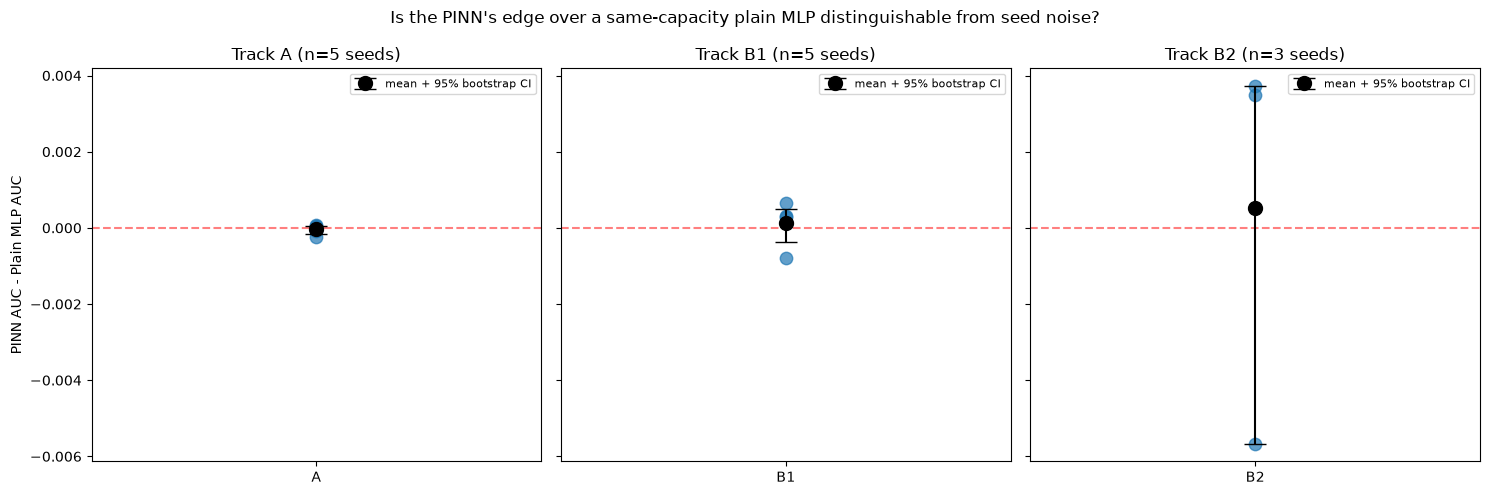

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\PINN_vs_MLP_Seed_Robustness.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, track in enumerate(["A", "B1", "B2"]):
    tdf = {"A": trackA_seed_df, "B1": trackB1_seed_df, "B2": trackB2_seed_df}[track]
    per_seed = tdf.groupby(["seed", "model"])["roc_auc"].mean().unstack("model")
    deltas = per_seed["PINN"] - per_seed["PlainMLP"]
    axes[i].axhline(0, color="red", linestyle="--", alpha=0.5)
    axes[i].scatter([track] * len(deltas), deltas, s=80, alpha=0.7)
    row = summary_df[summary_df["track"] == track].iloc[0]
    axes[i].errorbar([track], [row["mean_pinn_minus_mlp_auc"]],
                      yerr=[[row["mean_pinn_minus_mlp_auc"] - row["ci_95_lo"]],
                            [row["ci_95_hi"] - row["mean_pinn_minus_mlp_auc"]]],
                      fmt="ko", capsize=8, markersize=10, label="mean + 95% bootstrap CI")
    axes[i].set_title(f"Track {track} (n={row['n_seeds']} seeds)")
    axes[i].legend(fontsize=8)
axes[0].set_ylabel("PINN AUC - Plain MLP AUC")
plt.suptitle("Is the PINN's edge over a same-capacity plain MLP distinguishable from seed noise?")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "PINN_vs_MLP_Seed_Robustness.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'PINN_vs_MLP_Seed_Robustness.png')}")


In [11]:
print("=" * 70)
print("  STEP 7b -- SEED ROBUSTNESS CHECK COMPLETE")
print("=" * 70)
print(f"  Total wall time: {time.time()-PIPELINE_T0:.1f} sec ({(time.time()-PIPELINE_T0)/60:.1f} min)")
for _, row in summary_df.iterrows():
    verdict = "PINN significantly beats plain MLP" if row["ci_excludes_zero"] and row["mean_pinn_minus_mlp_auc"] > 0 \
        else ("plain MLP significantly beats PINN" if row["ci_excludes_zero"] else "no significant difference")
    print(f"  Track {row['track']}: {verdict}  (mean delta {row['mean_pinn_minus_mlp_auc']:+.4f}, "
          f"95% CI [{row['ci_95_lo']:+.4f}, {row['ci_95_hi']:+.4f}])")


  STEP 7b -- SEED ROBUSTNESS CHECK COMPLETE
  Total wall time: 9883.9 sec (164.7 min)
  Track A: no significant difference  (mean delta -0.0000, 95% CI [-0.0001, +0.0001])
  Track B1: no significant difference  (mean delta +0.0001, 95% CI [-0.0004, +0.0005])
  Track B2: no significant difference  (mean delta +0.0005, 95% CI [-0.0057, +0.0037])
